In [2]:
# ==============================
#  Import Required Libraries
# ==============================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [3]:
# ==============================
#  Define Dataset Paths
# ==============================

# Update these paths to your dataset directories
train_path = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\train'
valid_path = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\validation'
test_path  = r'C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test'

BATCH_SIZE = 16  # Recommended for medical dataset
IMG_SIZE = (224, 224)

In [4]:
# ==============================
#  Data Preprocessing
# ==============================

# ResNet50 requires its own preprocessing function
def tl_preprocess(x):
    return preprocess_input(x)

# Create ImageDataGenerators for train, validation, and test
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=tl_preprocess
)

tl_valid_datagen = ImageDataGenerator(
    preprocessing_function=tl_preprocess
)

tl_test_datagen = ImageDataGenerator(
    preprocessing_function=tl_preprocess
)

# Load images from directories
tl_train_generator = tl_train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

tl_valid_generator = tl_valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

tl_test_generator = tl_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 57832 images belonging to 4 classes.
Found 7232 images belonging to 4 classes.
Found 7232 images belonging to 4 classes.


In [5]:
# ==============================
#  Load Pretrained ResNet50
# ==============================

# Load ResNet50 pretrained on ImageNet
base_model = ResNet50(
    weights='imagenet',       # Use pretrained ImageNet weights
    include_top=False,        # Remove original classification head
    input_shape=(224,224,3)   # Input shape must match dataset
)

# Freeze the base model for feature extraction phase
base_model.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 234s 2us/step


In [6]:
# ==============================
#  Build Custom Classification Head
# ==============================

model = keras.Sequential([
    
    base_model,                              # Pretrained feature extractor
    
    keras.layers.GlobalAveragePooling2D(),   # Convert feature maps to vector
    
    keras.layers.BatchNormalization(),       # Stabilize training
    
    keras.layers.Dense(256, activation='relu'),  # Fully connected layer
    
    keras.layers.Dropout(0.5),               # Reduce overfitting
    
    keras.layers.Dense(4, activation='softmax')  # Output layer (4 classes)
])


In [7]:
# ==============================
#  Compile Model (Feature Extraction Phase)
# ==============================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # Small learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# ==============================
#  Callbacks (Professional Setup)
# ==============================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_resnet50_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]


In [9]:
# ==============================
#  Train (Feature Extraction)
# ==============================

history = model.fit(
    tl_train_generator,
    epochs=20,                    # EarlyStopping will stop automatically
    validation_data=tl_valid_generator,
    callbacks=callbacks
)

Epoch 1/20


C:\Users\hp\Desktop\Brave_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.8167 - loss: 0.5191
Epoch 1: val_loss improved from inf to 0.19073, saving model to best_resnet50_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 3564s 984ms/step - accuracy: 0.8167 - loss: 0.5190 - val_accuracy: 0.9322 - val_loss: 0.1907 - learning_rate: 1.0000e-04
Epoch 2/20
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.9125 - loss: 0.2478
Epoch 2: val_loss improved from 0.19073 to 0.15409, saving model to best_resnet50_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 3338s 923ms/step - accuracy: 0.9125 - loss: 0.2478 - val_accuracy: 0.9468 - val_loss: 0.1541 - learning_rate: 1.0000e-04
Epoch 3/20
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.9319 - loss: 0.1912
Epoch 3: val_loss improved from 0.15409 to 0.14075, saving model to best_resnet50_model.keras
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 3341s 924ms/step - accuracy: 0.9319 - loss: 0.1912 - val_accuracy: 0.9508 - val_loss: 0.1407 - learning_rate: 1.0000e-04
Epoch 4

In [31]:
# ==============================
# Fine-Tuning Phase
# ==============================

# Unfreeze last 20 layers of ResNet50
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train again (fine-tuning)
fine_tune_history = model.fit(
    tl_train_generator,
    epochs=15,
    validation_data=tl_valid_generator,
    callbacks=callbacks
)

Epoch 1/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7496 - loss: 0.7064
Epoch 1: val_loss did not improve from 0.09295
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 4187s 1s/step - accuracy: 0.7496 - loss: 0.7063 - val_accuracy: 0.9392 - val_loss: 0.1757 - learning_rate: 1.0000e-05
Epoch 2/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9258 - loss: 0.2205
Epoch 2: val_loss did not improve from 0.09295
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 4300s 1s/step - accuracy: 0.9258 - loss: 0.2205 - val_accuracy: 0.9562 - val_loss: 0.1242 - learning_rate: 1.0000e-05
Epoch 3/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9526 - loss: 0.1370
Epoch 3: val_loss did not improve from 0.09295
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 4088s 1s/step - accuracy: 0.9526 - loss: 0.1370 - val_accuracy: 0.9628 - val_loss: 0.1092 - learning_rate: 1.0000e-05
Epoch 4/15
3615/3615 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9689 - loss: 0.0898
Epoch 4: val_loss did not improve from 0.09295
3615/3615 ━━━━━━━

In [32]:
# ==============================
#  Evaluate Model
# ==============================

test_loss, test_accuracy = model.evaluate(tl_test_generator)

print("Test Accuracy:", test_accuracy)

452/452 ━━━━━━━━━━━━━━━━━━━━ 380s 840ms/step - accuracy: 0.9435 - loss: 0.1695
Test Accuracy: 0.944275438785553


452/452 ━━━━━━━━━━━━━━━━━━━━ 352s 777ms/step


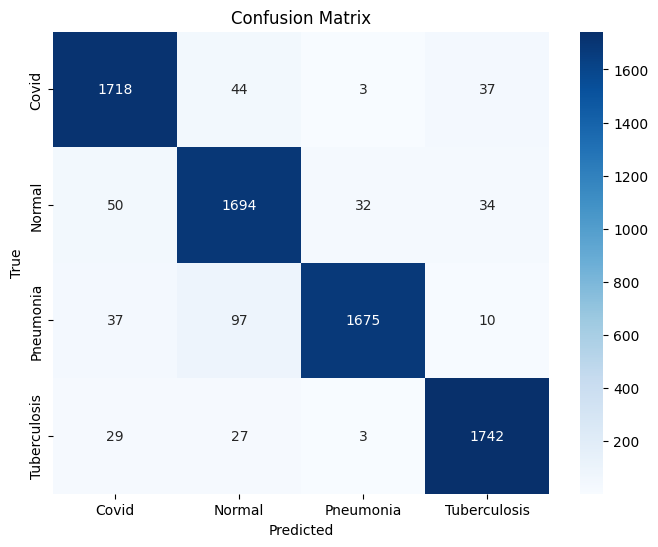

Classification Report:

              precision    recall  f1-score   support

       Covid       0.94      0.95      0.94      1802
      Normal       0.91      0.94      0.92      1810
   Pneumonia       0.98      0.92      0.95      1819
Tuberculosis       0.96      0.97      0.96      1801

    accuracy                           0.94      7232
   macro avg       0.94      0.94      0.94      7232
weighted avg       0.95      0.94      0.94      7232



In [33]:
# ==============================
# Confusion Matrix & Classification Report
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
Y_pred = model.predict(tl_test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = tl_test_generator.classes

# Class labels
class_labels = list(tl_test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

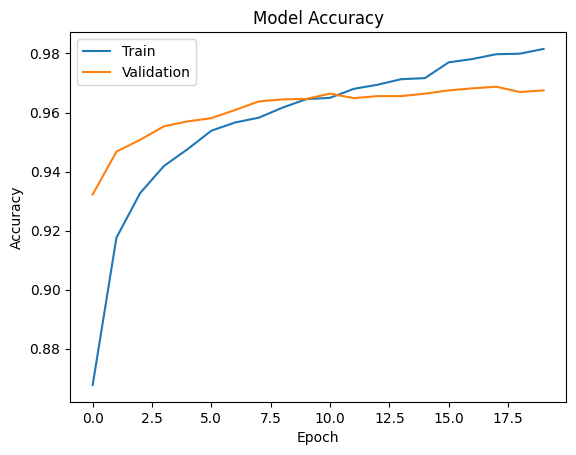

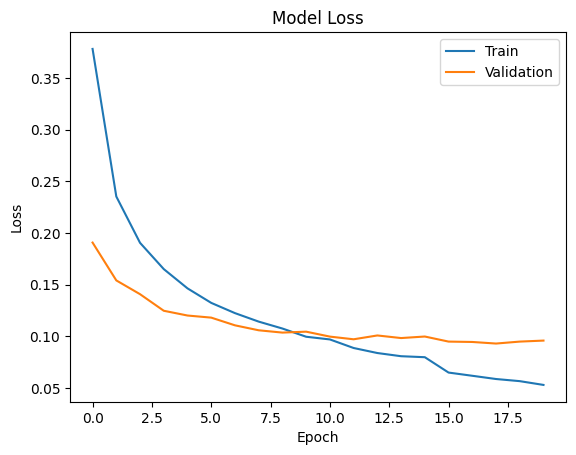

In [34]:
# ==============================
# Plot Training History
# ==============================

def plot_history(history):
    
    # Accuracy plot
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])
    plt.show()
    
    # Loss plot
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])
    plt.show()

plot_history(history)

In [35]:
# ==============================
# Functional Model (Grad-CAM Safe)
# ==============================

from tensorflow.keras import layers, Model

# Base model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# Define input explicitly
inputs = layers.Input(shape=(224,224,3))

# Forward pass through ResNet50
x = base_model(inputs, training=False)

# Custom head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation='softmax')(x)

# Create model
model = Model(inputs, outputs)

In [36]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Find base model (ResNet50)
    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            base_model = layer
            break

    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        [model.input],
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [30]:
model = load_model("best_resnet50_model.keras", compile=False, safe_mode=False)

ValueError: Layer "batch_normalization" expects 1 input(s), but it received 2 input tensors. Inputs received: [<KerasTensor shape=(None, 7, 7, 2048), dtype=float32, sparse=False, name=keras_tensor_2028>, <KerasTensor shape=(None, 7, 7, 2048), dtype=float32, sparse=False, name=keras_tensor_2029>]

In [21]:
img_path = r"C:\Users\hp\Desktop\Tuberculosis and Pneumonia\main Dataset\split_data\test\Covid\00f9707e0de334db70a7924a9de98368.jpg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

heatmap = make_gradcam_heatmap(img_array, model, "conv5_block3_out")

plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

KeyError: 'Exception encountered when calling Functional.call().\n\n\x1b[1m2588718862912\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[-103.939     , -116.779     , -123.68      ],\n         [-100.939     , -113.779     , -120.68      ],\n         [ -99.939     , -112.779     , -119.68      ],\n         ...,\n         [  25.060997  ,   12.221001  ,    5.3199997 ],\n         [  53.060997  ,   40.221     ,   33.32      ],\n         [  57.060997  ,   44.221     ,   37.32      ]],\n\n        [[-101.939     , -114.779     , -121.68      ],\n         [ -98.939     , -111.779     , -118.68      ],\n         [ -96.939     , -109.779     , -116.68      ],\n         ...,\n         [  13.060997  ,    0.22100067,   -6.6800003 ],\n         [  43.060997  ,   30.221     ,   23.32      ],\n         [  69.061     ,   56.221     ,   49.32      ]],\n\n        [[ -99.939     , -112.779     , -119.68      ],\n         [ -96.939     , -109.779     , -116.68      ],\n         [ -95

In [ ]:
for layer in model.layers:
    print(layer.name)